In [1]:
import pandas as pd
from ids_expt.core.defs import TOP_CIC_FEATURES

In [2]:
df_orig = pd.read_csv(r"E:\MSc Works\IDS\data\cicflow_combined.csv")
df_orig.columns = [col.strip() for col in df_orig.columns]
df_orig = df_orig[TOP_CIC_FEATURES + ["Label"]]

# remove row with nan or inf
df_orig = df_orig[~df_orig.isin([float("inf"), -float("inf")]).any(axis=1)]

df_orig.Label.value_counts()

Label
NORMAL                 14705
DISABLE_UNSOLICITED     5760
COLD_RESTART            5760
WARM_RESTART            5760
DNP3_ENUMERATE          3368
DNP3_INFO               3340
ARP_POISONING            835
INIT_DATA                720
STOP_APP                 720
REPLAY                   666
MITM_DOS                 130
Name: count, dtype: int64

### Merge Generated

In [28]:
from pathlib import Path

# merge and write
pd.concat(
    [
        pd.concat(
            [
                pd.read_csv(f)
                for f in Path(
                    r"E:\MSc Works\IDS\results\cic_ctgan_synthetic_data"
                ).glob("*.csv")
            ],
            ignore_index=True,
        ),
        df_orig,
    ]
).to_csv(
    r"E:\MSc Works\IDS\data\cic_ctgan_merged_synthetic_data.csv",
    index=False,
)

In [8]:
from pathlib import Path

df_gen = pd.concat(
    [
        pd.read_csv(f)
        for f in Path(r"E:\MSc Works\IDS\results\cic_ctgan_synthetic_data").glob(
            "*.csv"
        )
    ],
    ignore_index=True,
)
df_gen.columns = [col.strip() for col in df_gen.columns]
df_gen = df_gen[TOP_CIC_FEATURES + ["Label"]]
ndf_gen = pd.concat([df_gen, df_orig], ignore_index=True)

df_gen.Label.value_counts(), ndf_gen.Label.value_counts()

(Label
 MITM_DOS               14575
 REPLAY                 14039
 INIT_DATA              13985
 STOP_APP               13985
 ARP_POISONING          13870
 DNP3_INFO              11365
 DNP3_ENUMERATE         11337
 COLD_RESTART            8945
 DISABLE_UNSOLICITED     8945
 WARM_RESTART            8945
 Name: count, dtype: int64,
 Label
 ARP_POISONING          14705
 COLD_RESTART           14705
 DISABLE_UNSOLICITED    14705
 DNP3_ENUMERATE         14705
 DNP3_INFO              14705
 INIT_DATA              14705
 MITM_DOS               14705
 REPLAY                 14705
 STOP_APP               14705
 WARM_RESTART           14705
 NORMAL                 14705
 Name: count, dtype: int64)

In [9]:
# min_cnt = df_gen.Label.value_counts().min()
# df_gen = (
#     df_gen.groupby("Label")
#     .apply(lambda x: x.sample(min_cnt, random_state=42, replace=False))
#     .reset_index(drop=True)
# )
# df_gen.Label.value_counts()

### Statistic of Generated Data

In [29]:
import pandas as pd
from pathlib import Path

df_gen = pd.concat(
    [
        pd.read_csv(f)
        for f in Path(r"E:\MSc Works\IDS\results\cic_ctgan_synthetic_data").glob(
            "*.csv"
        )
    ],
    ignore_index=True,
)
df_gen.columns = [col.strip() for col in df_gen.columns]
df_gen.columns

Index(['Subflow Bwd Pkts', 'Bwd Header Len', 'Fwd Pkt Len Min', 'Tot Bwd Pkts',
       'Subflow Bwd Byts', 'Tot Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd IAT Mean',
       'Fwd Act Data Pkts', 'Fwd Header Len', 'Subflow Fwd Byts',
       'Fwd Pkt Len Std', 'Fwd Pkts/s', 'TotLen Fwd Pkts', 'Fwd Seg Size Avg',
       'Flow IAT Std', 'Flow Pkts/s', 'Flow Byts/s', 'Pkt Len Mean',
       'Fwd Pkt Len Mean', 'Pkt Size Avg', 'Flow IAT Mean', 'Subflow Fwd Pkts',
       'Bwd IAT Tot', 'Pkt Len Var', 'Bwd Pkt Len Mean', 'Fwd IAT Std',
       'Bwd IAT Mean', 'Init Bwd Win Byts', 'Dst Port', 'Fwd IAT Tot',
       'Bwd IAT Std', 'Bwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkts/s',
       'Flow Duration', 'Src Port', 'Label', 'is_synthetic', 'quality_score',
       'diagnostic_score'],
      dtype='object')

In [31]:
from ids_expt.core.defs import TOP_CIC_FEATURES

len(TOP_CIC_FEATURES)

37

C:\Users\Viper\AppData\Local\Temp\ipykernel_15664\293629202.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(first_values["Label"], rotation=45, ha="right")
C:\Users\Viper\AppData\Local\Temp\ipykernel_15664\293629202.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(first_values["Label"], rotation=45, ha="right")


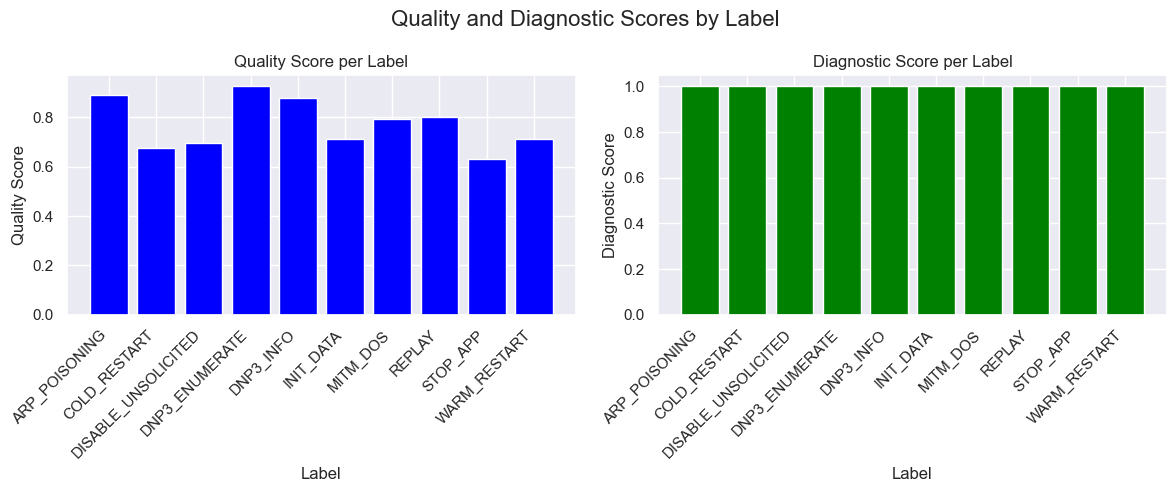

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

df = df_gen.copy()
first_values = (
    df.groupby("Label")
    .agg({"quality_score": "first", "diagnostic_score": "first"})
    .reset_index()
)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot for quality_score
axes[0].bar(first_values["Label"], first_values["quality_score"], color="blue")
axes[0].set_title("Quality Score per Label")
axes[0].set_xlabel("Label")
axes[0].set_xticklabels(first_values["Label"], rotation=45, ha="right")
axes[0].set_ylabel("Quality Score")

# Bar plot for diagnostic_score
axes[1].bar(first_values["Label"], first_values["diagnostic_score"], color="green")
axes[1].set_title("Diagnostic Score per Label")
axes[1].set_xlabel("Label")
axes[1].set_xticklabels(first_values["Label"], rotation=45, ha="right")
axes[1].set_ylabel("Diagnostic Score")

plt.tight_layout()
plt.suptitle("Quality and Diagnostic Scores by Label", fontsize=16)
plt.subplots_adjust(top=0.85)  # Adjust title position
plt.savefig(
    r"E:\MSc Works\IDS\results\cic_ctgan_synthetic_data\quality_diagnostic_scores.pdf"
)
plt.show()

In [44]:
from ids_expt.core.defs import TOP_CIC_FEATURES
from scipy.stats import ks_2samp
import numpy as np

df_orig = pd.read_csv(r"E:\MSc Works\IDS\data\cicflow_combined.csv")
df.columns = [col.strip() for col in df.columns]
# find ks_score between numerical columns of
results = []
for label in df_orig.Label.unique():
    if label == "NORMAL":
        continue
    df_label = df_orig[df_orig.Label == label]
    df_gen_label = df_gen[df_gen.Label == label]
    ks_scores = []
    for col in TOP_CIC_FEATURES:
        if np.issubdtype(df_label[col].dtype, np.number) and np.issubdtype(
            df_gen_label[col].dtype, np.number
        ):
            ks_stat, p_value = ks_2samp(df_label[col], df_gen_label[col])
            results.append(
                {
                    "label": label,
                    "feature": col,
                    "ks_statistic": ks_stat,
                    "p_value": p_value,
                }
            )

In [45]:
# p<0.05: reject null hypothesis. The two samples likely come from different distributions
# ks_statistic close to 0: the two samples are from the same distribution

results_df = pd.DataFrame(results)
agg_df = (
    results_df.groupby("label")
    .agg(
        {
            "ks_statistic": "mean",
            "p_value": "mean",
        }
    )
    .reset_index()
    .sort_values(by="ks_statistic", ascending=False)
)

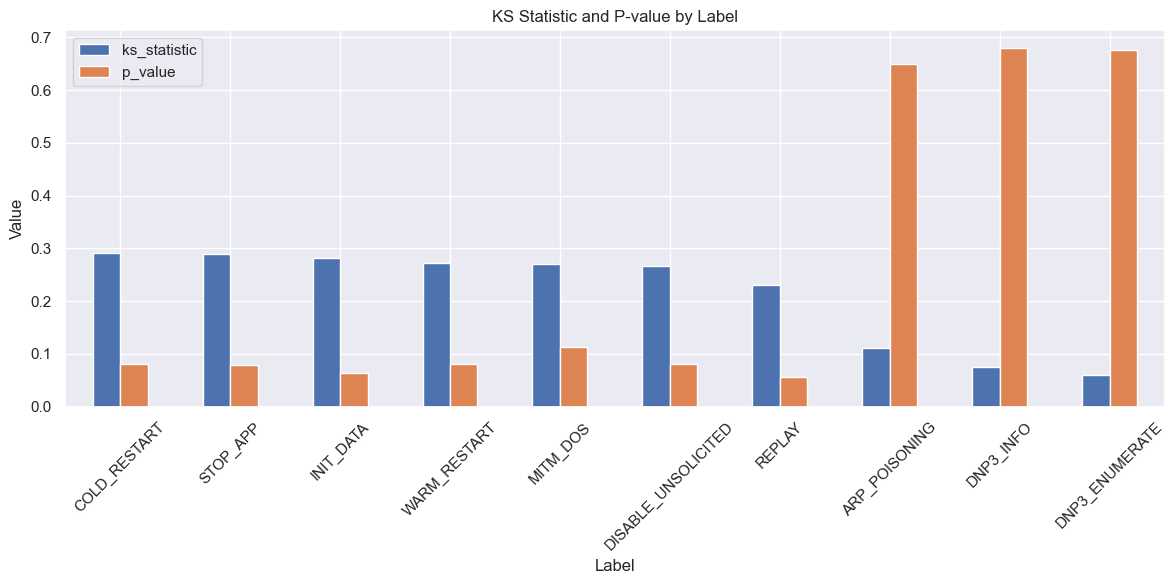

In [46]:
# plot bar for p and ks
sns.set()
agg_df.plot(
    x="label",
    y=["ks_statistic", "p_value"],
    kind="bar",
    figsize=(12, 6),
    title="KS Statistic and P-value by Label",
)
plt.ylabel("Value")
plt.xlabel("Label")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    r"E:\MSc Works\IDS\results\cic_ctgan_synthetic_data\ks_statistic_p_value_by_label.pdf"
)
plt.show()

### Train on all and Test only on Real Data

In [39]:
# scaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df_gen = pd.concat(
    [
        pd.read_csv(f)
        for f in Path(r"E:\MSc Works\IDS\results\cic_ctgan_synthetic_data").glob(
            "*.csv"
        )
    ],
    ignore_index=True,
)
df_gen.columns = [col.strip() for col in df_gen.columns]
# df_gen = df_gen[TOP_CIC_FEATURES + ["Label"]]
df_gen = pd.concat([df_gen, df_orig], ignore_index=True)

df_train, df_test = train_test_split(
    df_gen, test_size=0.2, random_state=42, stratify=df_gen.Label
)
df_test = df_test.query("Label!='NORMAL' or is_synthetic!=True")[
    TOP_CIC_FEATURES + ["Label"]
]
df_train = df_train[TOP_CIC_FEATURES + ["Label"]]

scaler = StandardScaler()
X_train = df_train.drop(columns=["Label"])
X_test = df_test.drop(columns=["Label"])
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, df_train.Label)

RandomForestClassifier(random_state=42)

In [40]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

y_pred = rf.predict(X_test_scaled)
print(classification_report(df_test.Label, y_pred))
print(confusion_matrix(df_test.Label, y_pred))
print("F1 Score:", f1_score(df_test.Label, y_pred, average="weighted"))

                     precision    recall  f1-score   support

      ARP_POISONING       1.00      1.00      1.00      2941
       COLD_RESTART       0.99      0.99      0.99      2941
DISABLE_UNSOLICITED       1.00      1.00      1.00      2941
     DNP3_ENUMERATE       0.96      0.96      0.96      2941
          DNP3_INFO       0.96      0.96      0.96      2941
          INIT_DATA       1.00      1.00      1.00      2941
           MITM_DOS       1.00      1.00      1.00      2941
             NORMAL       0.99      0.99      0.99      2941
             REPLAY       0.99      0.99      0.99      2941
           STOP_APP       1.00      1.00      1.00      2941
       WARM_RESTART       0.99      0.99      0.99      2941

           accuracy                           0.99     32351
          macro avg       0.99      0.99      0.99     32351
       weighted avg       0.99      0.99      0.99     32351

[[2941    0    0    0    0    0    0    0    0    0    0]
 [   0 2901    0    0   

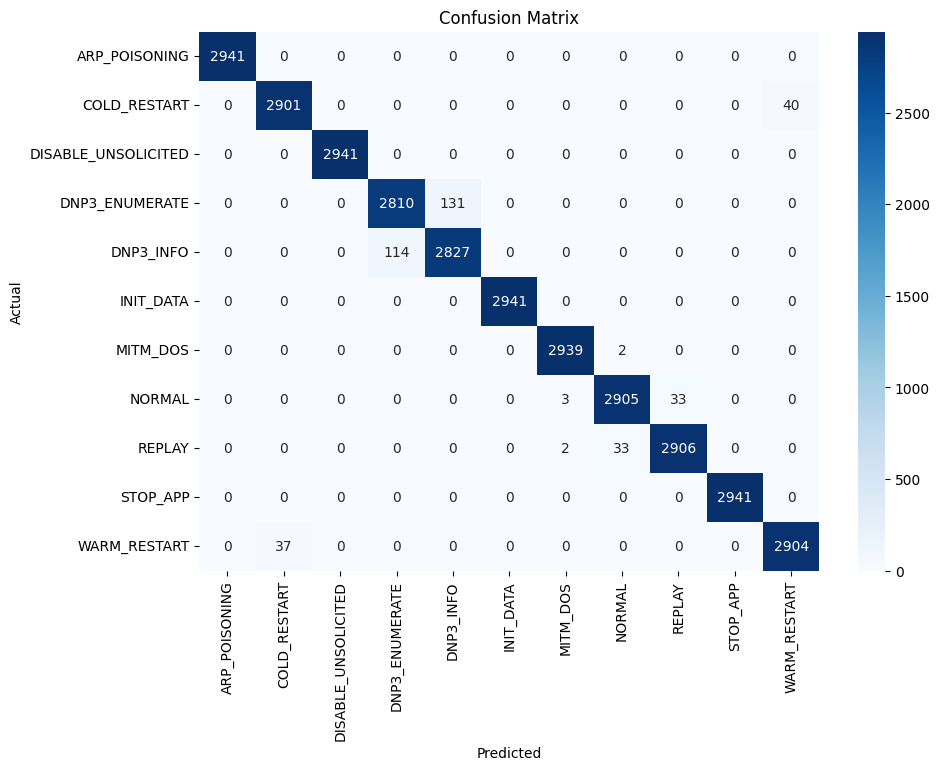

In [41]:
# plot confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(df_test.Label, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=rf.classes_,
    yticklabels=rf.classes_,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Train on Generated Test on Non Generated

In [35]:
df_gen = pd.concat(
    [
        pd.read_csv(f)
        for f in Path(r"E:\MSc Works\IDS\results\cic_ctgan_synthetic_data").glob(
            "*.csv"
        )
    ],
    ignore_index=True,
)
df_gen.columns = [col.strip() for col in df_gen.columns]
df_gen = pd.concat([df_gen, df_orig], ignore_index=True)
df_gen = df_gen.query('Label=="NORMAL" or is_synthetic==True')
df_train, df_test = train_test_split(
    df_gen,
    test_size=0.2,
    random_state=42,
    stratify=df_gen.Label,
)
df_train = df_train[TOP_CIC_FEATURES + ["Label"]]
df_test = df_test[TOP_CIC_FEATURES + ["Label"]]
scaler = StandardScaler()
X_train = df_train.drop(columns=["Label"])
X_test = df_test.drop(columns=["Label"])
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, df_train.Label)

RandomForestClassifier(random_state=42)

In [36]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

X_test_scaled = scaler.transform(df_orig[TOP_CIC_FEATURES])

y_pred = rf.predict(X_test_scaled)
print(classification_report(df_orig.Label, y_pred))
print(confusion_matrix(df_orig.Label, y_pred))
print("F1 Score:", f1_score(df_orig.Label, y_pred, average="weighted"))

e:\MSc Works\IDS\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
e:\MSc Works\IDS\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
e:\MSc Works\IDS\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                     precision    recall  f1-score   support

      ARP_POISONING       1.00      1.00      1.00       835
       COLD_RESTART       0.61      0.02      0.04      5760
DISABLE_UNSOLICITED       1.00      1.00      1.00      5760
     DNP3_ENUMERATE       0.93      0.70      0.80      3368
          DNP3_INFO       0.76      0.94      0.84      3340
          INIT_DATA       0.50      0.98      0.66       720
           MITM_DOS       1.00      0.09      0.17       130
             NORMAL       0.95      1.00      0.97     14705
             REPLAY       0.33      0.00      0.00       666
           STOP_APP       0.00      0.00      0.00       720
       WARM_RESTART       0.50      0.99      0.67      5760

           accuracy                           0.80     41764
          macro avg       0.69      0.61      0.56     41764
       weighted avg       0.80      0.80      0.74     41764

[[  835     0     0     0     0     0     0     0     0     0     0]
 [    0   111

In [1]:
import pandas as pd

pd.read_csv(r"E:\MSc Works\IDS\model_evaluation_results.csv")

,data_type,model,accuracy,f1,precision,recall
0,cicflow_combined,RandomForestClassifier,0.958625,0.959709,0.962127,0.958625
1,cicflow_combined,GaussianNB,0.605114,0.608246,0.782369,0.605114
2,cicflow_combined,DecisionTreeClassifier,0.974236,0.974842,0.975833,0.974236
3,cicflow_combined,KNeighborsClassifier,0.963701,0.965963,0.970693,0.963701
4,cic_ctgan_merged_synthetic_data,RandomForestClassifier,0.968298,0.968214,0.968218,0.968298
5,cic_ctgan_merged_synthetic_data,GaussianNB,0.602624,0.605898,0.774454,0.602624
6,cic_ctgan_merged_synthetic_data,DecisionTreeClassifier,0.972704,0.972716,0.972753,0.972704
7,cic_ctgan_merged_synthetic_data,KNeighborsClassifier,0.963030,0.962765,0.962984,0.963030


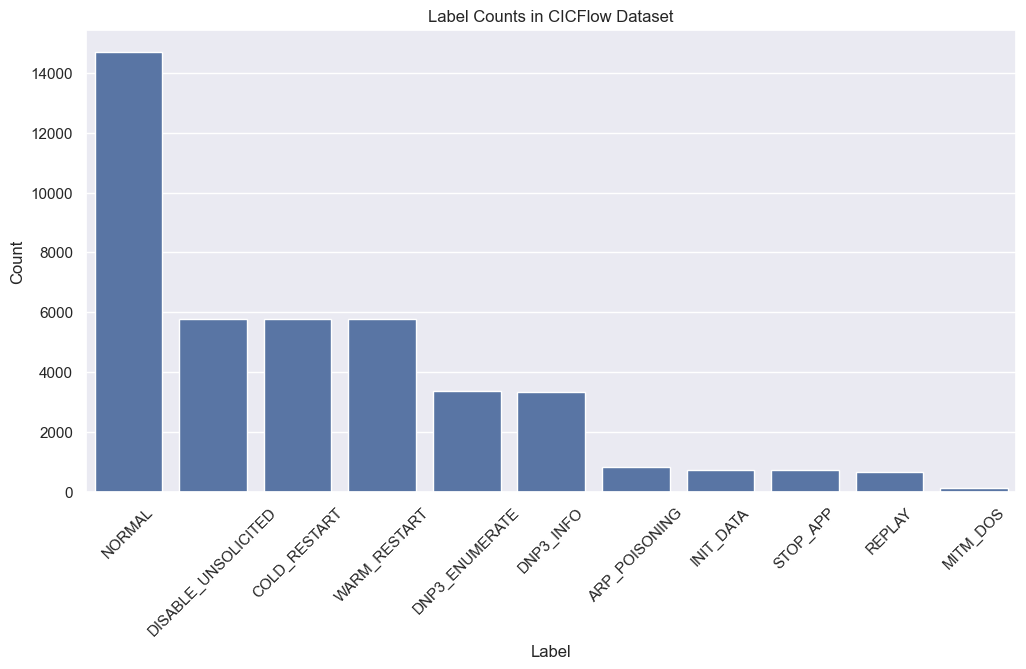

In [40]:
df = pd.read_csv(r"E:\MSc Works\IDS\data\cicflow_combined.csv")
df.columns = [col.strip() for col in df.columns]

# plot bar for label counts
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="Label", order=df.Label.value_counts().index)
plt.title("Label Counts in CICFlow Dataset")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.savefig(
    r"E:\MSc Works\IDS\results\cic_label_counts.pdf",
    bbox_inches="tight",
)
plt.show()

## Model Summary

In [ ]:
import torch
from torchsummary import summary
from ids_expt.models.ffnn import FFNN

model = FFNN(input_size=37, output_size=11, use_batchnorm=False)
model.load_state_dict(
    torch.load(r"E:\MSc Works\IDS\results\cic_fnn\ctgan_oversampling\best_model.pth"),
    True,
)
summary(model, torch.rand(1, 37))

C:\Users\Viper\AppData\Local\Temp\ipykernel_9980\2118230806.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(r"E:\MSc Works\IDS\results\cic_fnn\ctgan_oversampl

<All keys matched successfully>

In [36]:
from ids_expt.models.cnn import BiggerCNN2D

model = BiggerCNN2D()
model.load_state_dict(
    torch.load(
        r"E:\MSc Works\IDS\results\pcap_image_classification\bigger_cnn2d\best_model.pth"
    )
)

C:\Users\Viper\AppData\Local\Temp\ipykernel_9980\1382510278.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


<All keys matched successfully>

In [40]:
summary(model, torch.rand(1, 1, 192, 256))

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 128, 1, 1]           --
|    └─Conv2d: 2-1                       [-1, 32, 192, 256]        320
|    └─BatchNorm2d: 2-2                  [-1, 32, 192, 256]        64
|    └─ReLU: 2-3                         [-1, 32, 192, 256]        --
|    └─MaxPool2d: 2-4                    [-1, 32, 96, 128]         --
|    └─Conv2d: 2-5                       [-1, 64, 96, 128]         18,496
|    └─BatchNorm2d: 2-6                  [-1, 64, 96, 128]         128
|    └─ReLU: 2-7                         [-1, 64, 96, 128]         --
|    └─MaxPool2d: 2-8                    [-1, 64, 48, 64]          --
|    └─Conv2d: 2-9                       [-1, 128, 48, 64]         73,856
|    └─BatchNorm2d: 2-10                 [-1, 128, 48, 64]         256
|    └─ReLU: 2-11                        [-1, 128, 48, 64]         --
|    └─AdaptiveAvgPool2d: 2-12           [-1, 128, 1, 1]           --
├─Se

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 128, 1, 1]           --
|    └─Conv2d: 2-1                       [-1, 32, 192, 256]        320
|    └─BatchNorm2d: 2-2                  [-1, 32, 192, 256]        64
|    └─ReLU: 2-3                         [-1, 32, 192, 256]        --
|    └─MaxPool2d: 2-4                    [-1, 32, 96, 128]         --
|    └─Conv2d: 2-5                       [-1, 64, 96, 128]         18,496
|    └─BatchNorm2d: 2-6                  [-1, 64, 96, 128]         128
|    └─ReLU: 2-7                         [-1, 64, 96, 128]         --
|    └─MaxPool2d: 2-8                    [-1, 64, 48, 64]          --
|    └─Conv2d: 2-9                       [-1, 128, 48, 64]         73,856
|    └─BatchNorm2d: 2-10                 [-1, 128, 48, 64]         256
|    └─ReLU: 2-11                        [-1, 128, 48, 64]         --
|    └─AdaptiveAvgPool2d: 2-12           [-1, 128, 1, 1]           --
├─Se

In [20]:
model

<All keys matched successfully>